In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (Input, Embedding, Bidirectional, LSTM, Conv1D, Conv2D, GlobalMaxPooling1D,
                                    BatchNormalization, Concatenate, Dense, Dropout, MaxPooling2D, Flatten)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

In [20]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving test_split.csv to test_split.csv
Saving train_split.csv to train_split.csv
Saving val_split.csv to val_split.csv
User uploaded file "test_split.csv" with length 176691 bytes
User uploaded file "train_split.csv" with length 822708 bytes
User uploaded file "val_split.csv" with length 176561 bytes


In [14]:
#Ouvrir le drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
text_df_train = pd.read_csv('/content/train_split.csv', on_bad_lines='skip')
text_df_test = pd.read_csv('/content/test_split.csv', on_bad_lines='skip')
text_df_val = pd.read_csv('/content/val_split.csv', on_bad_lines='skip')


In [23]:
text_df_train.head()

,ImageID,Labels,Caption,Labels_list
0,9306.jpg,17,A stuffed animal cat stands in a pair of shoes.,[17]
1,12244.jpg,11 10 3,A fire hydrant is sitting on a street corner.,"[11, 10, 3]"
2,28931.jpg,11,A red fire hydrant is on the curb in front of ...,[11]
3,29430.jpg,8,there is a very old rusted truck that is parke...,[8]
4,11288.jpg,6,The front of a metro bus picking up passengers,[6]


In [25]:
import zipfile
import os

# Chemin vers le fichier ZIP sur Google Drive
zip_file_path = '/content/drive/MyDrive/data.zip'

# Répertoire où décompresser les fichiers
extract_to_path = '/content/images'

# Créer le répertoire de destination s'il n'existe pas
os.makedirs(extract_to_path, exist_ok=True)

# Décompresser le fichier ZIP
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Vérifier les fichiers extraits
print(f"Fichiers extraits dans : {extract_to_path}")
!ls {extract_to_path}


Fichiers extraits dans : /content/images
data


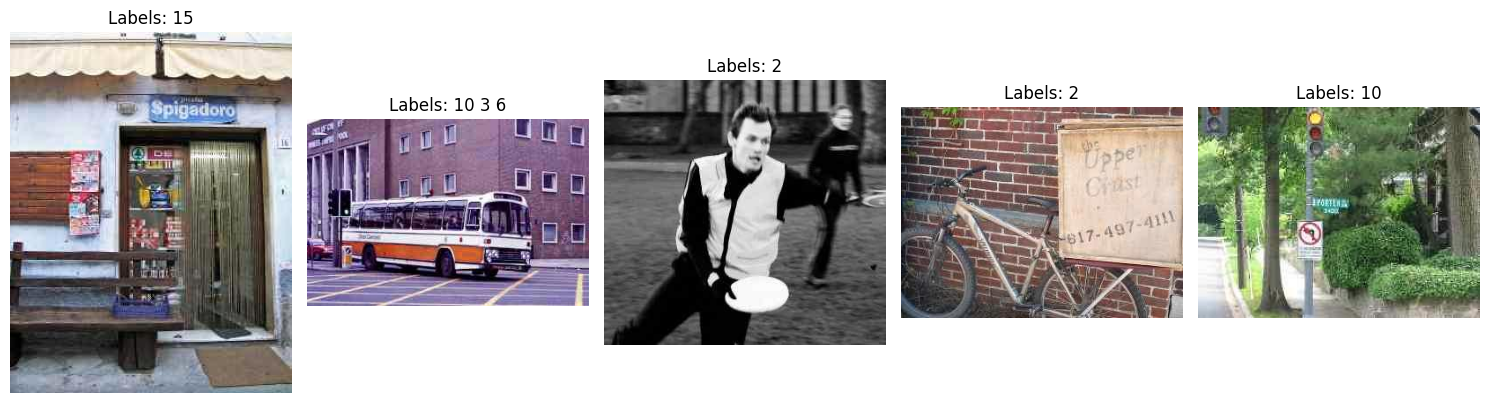

In [39]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Définir le dossier contenant les images
image_folder = "/content/images/data"

# Sélectionner aléatoirement 5 images du CSV
sample_df = text_df_train.sample(5, random_state=42)

plt.figure(figsize=(15, 5))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img_path = os.path.join(image_folder, row["ImageID"])
    img = Image.open(img_path).convert("RGB")

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f"Labels: {row['Labels']}")  # Afficher les labels
    plt.axis("off")

plt.tight_layout()
plt.show()


In [38]:
image_path = '/content/images/data'

In [42]:
import shutil

def copy_images(df, dest): # Change the csv_path to df
    # No need to read the CSV file, as the dataframe is passed directly
    # df = pd.read_csv(csv_path, on_bad_lines='warn')

    # Create the destination folder if it does not exist
    if not os.path.exists(dest):
        os.makedirs(dest)

    # Counters for the report
    copied = 0
    not_found = 0

    for image_id in df['ImageID']:
        image_path = os.path.join(image_folder, image_id)
        if os.path.exists(image_path):
            shutil.copy(image_path, dest)
            copied += 1
        else:
            print(f"Image not found: {image_id}")
            not_found += 1

    print(f"Copy completed for {dest}: {copied} images copied, {not_found} images not found")

In [43]:
image_train = '/content/images/train'
image_test = '/content/images/test'
image_val = '/content/images/val'

In [44]:
# Copier les images
copy_images(text_df_train, image_train)
copy_images(text_df_val, image_val)
copy_images(text_df_test, image_test)

Copy completed for /content/images/train: 11146 images copied, 0 images not found
Copy completed for /content/images/val: 2388 images copied, 0 images not found
Copy completed for /content/images/test: 2389 images copied, 0 images not found


In [46]:
test_images = '/content/images/test'
train_images = '/content/images/train'
val_images = '/content/images/val'

In [4]:
# --- Paramètres globaux ---
num_classes = 17  # Nombre de classes pour la classification multi-label
max_len = 100      # Longueur maximale des séquences de texte
max_words = 10000  # Taille du vocabulaire
embedding_dim = 300  # Dimensions des embeddings (GloVe 300D)
lstm_units = 128    # Nombre d'unités dans la couche LSTM

# Paramètres pour les images
IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS = 224, 224, 3  # Ajustez selon vos données

# 1. EXTRACTION DE CARACTÉRISTIQUES UNIMODALES

In [5]:
# 1.1 Modèle pour l'extraction de caractéristiques textuelles
def build_text_feature_extractor(embedding_matrix):
    # Input Layer
    text_input = Input(shape=(max_len,), name="Text_Input")

    # Embedding Layer avec les poids GloVe
    embedding_layer = Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        input_length=max_len,
        weights=[embedding_matrix],
        trainable=True,
        name="Text_Embedding"
    )(text_input)

    # Branche LSTM
    lstm_branch = Bidirectional(LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2, name="LSTM"))(embedding_layer)
    lstm_branch = Dropout(0.3, name="LSTM_Dropout")(lstm_branch)

    # Branche CNN 1D
    conv_branch = Conv1D(filters=128, kernel_size=3, activation='relu', name="Conv1D_1")(embedding_layer)
    conv_branch = BatchNormalization(name="BN_Conv1D_1")(conv_branch)
    conv_branch = Dropout(0.3, name="Dropout_Conv1D_1")(conv_branch)
    conv_branch = Conv1D(filters=128, kernel_size=3, activation='relu', name="Conv1D_2")(conv_branch)
    conv_branch = BatchNormalization(name="BN_Conv1D_2")(conv_branch)
    conv_branch = GlobalMaxPooling1D(name="GlobalMaxPool")(conv_branch)

    # Concatenation des branches LSTM et CNN
    text_features = Concatenate(name="Text_Features")([lstm_branch, conv_branch])

    # Créer le modèle d'extraction de caractéristiques textuelles
    text_feature_model = Model(inputs=text_input, outputs=text_features, name="Text_Feature_Extractor")
    return text_input, text_features, text_feature_model

In [6]:

# 1.2 Modèle pour l'extraction de caractéristiques d'images
def build_image_feature_extractor():
    # Input Layer pour les images
    image_input = Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), name="Image_Input")

    # Premier bloc de convolution
    x = Conv2D(32, (3, 3), padding='same', activation='relu', name="Conv2D_1")(image_input)
    x = BatchNormalization(name="BN_Conv2D_1")(x)
    x = Conv2D(32, (3, 3), padding='same', activation='relu', name="Conv2D_2")(x)
    x = BatchNormalization(name="BN_Conv2D_2")(x)
    x = MaxPooling2D(pool_size=(2, 2), name="MaxPool_1")(x)
    x = Dropout(0.25, name="Dropout_1")(x)

    # Deuxième bloc de convolution
    x = Conv2D(64, (3, 3), padding='same', activation='relu', name="Conv2D_3")(x)
    x = BatchNormalization(name="BN_Conv2D_3")(x)
    x = Conv2D(64, (3, 3), padding='same', activation='relu', name="Conv2D_4")(x)
    x = BatchNormalization(name="BN_Conv2D_4")(x)
    x = MaxPooling2D(pool_size=(2, 2), name="MaxPool_2")(x)
    x = Dropout(0.25, name="Dropout_2")(x)

    # Troisième bloc de convolution
    x = Conv2D(128, (3, 3), padding='same', activation='relu', name="Conv2D_5")(x)
    x = BatchNormalization(name="BN_Conv2D_5")(x)
    x = Conv2D(128, (3, 3), padding='same', activation='relu', name="Conv2D_6")(x)
    x = BatchNormalization(name="BN_Conv2D_6")(x)
    x = MaxPooling2D(pool_size=(2, 2), name="MaxPool_3")(x)
    x = Dropout(0.25, name="Dropout_3")(x)

    # Extraction des caractéristiques
    x = Flatten(name="Flatten")(x)
    image_features = Dense(512, activation='relu', name="Image_Features")(x)
    image_features = BatchNormalization(name="BN_Image_Features")(image_features)
    image_features = Dropout(0.5, name="Dropout_Image_Features")(image_features)

    # Créer le modèle d'extraction de caractéristiques d'images
    image_feature_model = Model(inputs=image_input, outputs=image_features, name="Image_Feature_Extractor")
    return image_input, image_features, image_feature_model

#  2. FUSION MULTIMODALE

In [7]:

def build_multimodal_fusion_model(text_input, text_features, image_input, image_features):
    # Concaténation des caractéristiques textuelles et visuelles
    fusion_features = Concatenate(name="Multimodal_Fusion")([text_features, image_features])

    # Couches denses pour la classification finale
    x = Dense(256, activation='relu', name="Fusion_Dense_1")(fusion_features)
    x = BatchNormalization(name="BN_Fusion_1")(x)
    x = Dropout(0.5, name="Dropout_Fusion_1")(x)

    x = Dense(128, activation='relu', name="Fusion_Dense_2")(x)
    x = BatchNormalization(name="BN_Fusion_2")(x)
    x = Dropout(0.3, name="Dropout_Fusion_2")(x)

    # Couche de sortie pour la classification multi-label
    outputs = Dense(num_classes, activation='sigmoid', name="Output")(x)

    # Créer le modèle complet
    fusion_model = Model(inputs=[text_input, image_input], outputs=outputs, name="Multimodal_Fusion_Model")

    return fusion_model

# 3. COMPILATION, ENTRAÎNEMENT ET ÉVALUATION

In [8]:

def compile_and_train_model(model, X_text_train, X_image_train, y_train, X_text_val, X_image_val, y_val):
    # Compilation du modèle
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    # Callbacks pour améliorer l'entraînement
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]

    # Entraînement du modèle
    history = model.fit(
        [X_text_train, X_image_train],
        y_train,
        batch_size=32,
        epochs=20,
        validation_data=([X_text_val, X_image_val], y_val),
        callbacks=callbacks,
        verbose=1
    )

    return model, history

# 4. COMPARAISON DES MODÈLES

In [9]:

def evaluate_and_compare_models(fusion_model, text_model, image_model, X_text_test, X_image_test, y_test):
    # Évaluation du modèle de fusion
    fusion_results = fusion_model.evaluate([X_text_test, X_image_test], y_test, verbose=1)

    # Évaluation du modèle textuel
    text_results = text_model.evaluate(X_text_test, y_test, verbose=1)

    # Évaluation du modèle d'images
    image_results = image_model.evaluate(X_image_test, y_test, verbose=1)

    # Afficher les résultats comparatifs
    metrics = ['loss', 'accuracy', 'precision', 'recall', 'auc']
    models = ['Modèle Fusion', 'Modèle Texte', 'Modèle Image']
    results = [fusion_results, text_results, image_results]

    print("\n--- COMPARAISON DES PERFORMANCES ---")
    print(f"{'Métrique':<15} | {'Fusion':<15} | {'Texte':<15} | {'Image':<15}")
    print("-" * 65)

    for i, metric in enumerate(metrics):
        print(f"{metric:<15} | {fusion_results[i]:<15.4f} | {text_results[i]:<15.4f} | {image_results[i]:<15.4f}")

    # Visualisation des performances
    plt.figure(figsize=(12, 8))

    for i, metric in enumerate(metrics):
        if i > 0:  # Skip loss
            plt.subplot(2, 2, i)
            values = [results[j][i] for j in range(3)]
            plt.bar(models, values)
            plt.title(f"Comparaison - {metric}")
            plt.ylim(0, 1)
            plt.xticks(rotation=30)

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=300)
    plt.show()

    return fusion_results, text_results, image_results

# 5. FONCTION PRINCIPALE POUR EXÉCUTER LE PIPELINE COMPLET

In [12]:

def build_and_train_multimodal_system(embedding_matrix, X_text_train, X_image_train, y_train,
                                       X_text_val, X_image_val, y_val,
                                       X_text_test, X_image_test, y_test):
    print("1. Construction des extracteurs de caractéristiques...")
    # Modèle textuel
    text_input, text_features, text_feature_model = build_text_feature_extractor(embedding_matrix)

    # Modèle d'images
    image_input, image_features, image_feature_model = build_image_feature_extractor()

    print("2. Construction du modèle de fusion multimodale...")
    # Modèle de fusion
    fusion_model = build_multimodal_fusion_model(text_input, text_features, image_input, image_features)
    fusion_model.summary()

    print("3. Construction des modèles unimodaux pour comparaison...")
    # Modèle textuel complet
    text_output = Dense(128, activation='relu')(text_features)
    text_output = Dropout(0.3)(text_output)
    text_output = Dense(num_classes, activation='sigmoid')(text_output)
    text_model = Model(inputs=text_input, outputs=text_output, name="Text_Only_Model")

    # Modèle d'images complet
    image_output = Dense(128, activation='relu')(image_features)
    image_output = Dropout(0.3)(image_output)
    image_output = Dense(num_classes, activation='sigmoid')(image_output)
    image_model = Model(inputs=image_input, outputs=image_output, name="Image_Only_Model")

    print("4. Compilation et entraînement des modèles...")
    # Entraînement du modèle de fusion
    fusion_model, fusion_history = compile_and_train_model(
        fusion_model, X_text_train, X_image_train, y_train, X_text_val, X_image_val, y_val
    )

    # Entraînement du modèle textuel
    text_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall', 'auc']
    )
    text_history = text_model.fit(
        X_text_train, y_train,
        batch_size=32, epochs=20,
        validation_data=(X_text_val, y_val),
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
    )

    # Entraînement du modèle d'images
    image_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall', 'auc']
    )
    image_history = image_model.fit(
        X_image_train, y_train,
        batch_size=32, epochs=20,
        validation_data=(X_image_val, y_val),
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
    )

    print("5. Évaluation et comparaison des modèles...")
    # Évaluation comparative
    fusion_results, text_results, image_results = evaluate_and_compare_models(
        fusion_model, text_model, image_model, X_text_test, X_image_test, y_test
    )



NameError: name 'fusion_history' is not defined

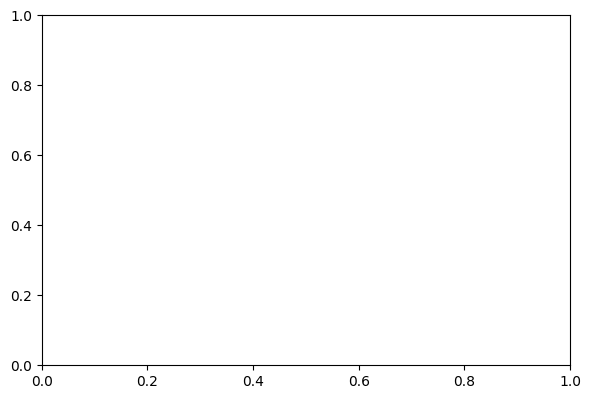

In [13]:

    # Visualisation des courbes d'apprentissage
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    plt.plot(fusion_history.history['loss'], label='Fusion - Train')
    plt.plot(fusion_history.history['val_loss'], label='Fusion - Val')
    plt.plot(text_history.history['loss'], label='Texte - Train')
    plt.plot(text_history.history['val_loss'], label='Texte - Val')
    plt.plot(image_history.history['loss'], label='Image - Train')
    plt.plot(image_history.history['val_loss'], label='Image - Val')
    plt.title('Courbes de perte')
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(fusion_history.history['accuracy'], label='Fusion - Train')
    plt.plot(fusion_history.history['val_accuracy'], label='Fusion - Val')
    plt.plot(text_history.history['accuracy'], label='Texte - Train')
    plt.plot(text_history.history['val_accuracy'], label='Texte - Val')
    plt.plot(image_history.history['accuracy'], label='Image - Train')
    plt.plot(image_history.history['val_accuracy'], label='Image - Val')
    plt.title('Précision')
    plt.legend()

    plt.tight_layout()
    plt.savefig('learning_curves.png', dpi=300)
    plt.show()

    return fusion_model, text_model, image_model, fusion_results, text_results, image_results
